**NOTE: THIS NOTEBOOK WAS RUN USING GOOGLE COLAB ON A T4 GPU**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import inspect
from timm.models.vision_transformer import VisionTransformer

print(inspect.signature(VisionTransformer.__init__))

(self, img_size: Union[int, Tuple[int, int]] = 224, patch_size: Union[int, Tuple[int, int]] = 16, in_chans: int = 3, num_classes: int = 1000, global_pool: Literal['', 'avg', 'avgmax', 'max', 'token', 'map', 'prr'] = 'token', embed_dim: int = 768, depth: int = 12, num_heads: int = 12, mlp_ratio: float = 4.0, qkv_bias: bool = True, qk_norm: bool = False, scale_attn_norm: bool = False, scale_mlp_norm: bool = False, proj_bias: bool = True, init_values: Optional[float] = None, class_token: bool = True, pos_embed: str = 'learn', no_embed_class: bool = False, reg_tokens: int = 0, pre_norm: bool = False, final_norm: bool = True, fc_norm: Optional[bool] = None, pool_include_prefix: bool = False, dynamic_img_size: bool = False, dynamic_img_pad: bool = False, drop_rate: float = 0.0, pos_drop_rate: float = 0.0, patch_drop_rate: float = 0.0, proj_drop_rate: float = 0.0, attn_drop_rate: float = 0.0, drop_path_rate: float = 0.0, weight_init: Literal['skip', 'reset', 'jax', 'jax_nlhb', 'moco', ''] = '

In [ ]:
%pip install optuna timm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 16.3 MB/s eta 0:00:00


## Importing packages

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline
import optuna
from optuna.trial import TrialState
import os
import pandas as pd
import pickle
import torch
import torch.nn as nn
import time
import psutil
import numpy as np
import seaborn as sns
import gc
import timm
from PIL import Image
from torch.utils.data import DataLoader, Dataset
from torchvision import models
from torchvision import transforms
from torchvision.transforms import v2 # Use torchvision.transforms if v2 isn't installed
from torchvision.transforms import InterpolationMode
from torchvision.models.swin_transformer import SwinTransformer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
# Utility function to print out memory (RAM) and processing (CPU) usage
def log_resource_usage(stage_name=""):
    process = psutil.Process(os.getpid())

    # RAM usage in Megabytes
    ram_usage_mb = process.memory_info().rss / (1024 * 1024)

    # CPU usage percentage (interval calculates usage over 0.1 seconds)
    cpu_usage_pct = psutil.cpu_percent(interval=1)

    print(f"--- [Resource Log: {stage_name}] ---")
    print(f"RAM Usage: {ram_usage_mb:.2f} MB")
    print(f"System CPU Usage: {cpu_usage_pct}%")
    print("-" * 35)

In [ ]:
!unzip -q "/content/drive/MyDrive/ICS5200 Files New.zip" "ICS5200 Files/data/*" "ICS5200 Files/dataset_final/*" -d "/content/"

In [ ]:
# Run this in a Colab cell before running your script
!cp -r "/content/drive/MyDrive/ICS5200 Files/data" "/content/data"

^C


In [ ]:
# Run this in a Colab cell before running your script
!cp -r "/content/drive/MyDrive/ICS5200 Files/dataset_final (1)" "/content/dataset_final"

^C


In [ ]:
target_directory = '/content/dataset_final'

def remove_suffix(directory):
    # walk from the bottom up so we don't change parent folder names before looking inside them
    for root, dirs, files in os.walk(directory, topdown=False):

        # Rename files first
        for file in files:
            if ' (1)' in file:
                # Split name and extension to ensure ' (1)' is removed correctly before the file type
                name, ext = os.path.splitext(file)
                if name.endswith(' (1)'):
                    new_name = name[:-4] + ext # Removes the last 4 characters ' (1)'

                    old_file_path = os.path.join(root, file)
                    new_file_path = os.path.join(root, new_name)

                    os.rename(old_file_path, new_file_path)
                    print(f"Renamed file: {file} -> {new_name}")

        # Rename subfolders
        for folder in dirs:
            if folder.endswith(' (1)'):
                new_folder_name = folder[:-4]

                old_folder_path = os.path.join(root, folder)
                new_folder_path = os.path.join(root, new_folder_name)

                os.path.join(root, folder)
                os.rename(old_folder_path, new_folder_path)
                print(f"Renamed folder: {folder} -> {new_folder_name}")

# 2. Run the function
remove_suffix(target_directory)
print("--- Renaming Complete! ---")

Renamed file: 0066 (1).png -> 0066.png
Renamed file: 0049 (1).png -> 0049.png
Renamed file: 0094 (1).png -> 0094.png
Renamed file: 0100 (1).png -> 0100.png
Renamed file: 0086 (1).png -> 0086.png
Renamed file: 0089 (1).png -> 0089.png
Renamed file: 0076 (1).png -> 0076.png
Renamed file: 0065 (1).png -> 0065.png
Renamed file: 0079 (1).png -> 0079.png
Renamed file: 0063 (1).png -> 0063.png
Renamed file: 0048 (1).png -> 0048.png
Renamed file: 0088 (1).png -> 0088.png
Renamed file: 0055 (1).png -> 0055.png
Renamed file: 0058 (1).png -> 0058.png
Renamed file: 0081 (1).png -> 0081.png
Renamed file: 0051 (1).png -> 0051.png
Renamed file: 0059 (1).png -> 0059.png
Renamed file: 0067 (1).png -> 0067.png
Renamed file: 0084 (1).png -> 0084.png
Renamed file: 0101 (1).png -> 0101.png
Renamed file: 0085 (1).png -> 0085.png
Renamed file: 0082 (1).png -> 0082.png
Renamed file: 0070 (1).png -> 0070.png
Renamed file: 0064 (1).png -> 0064.png
Renamed file: listing_urls_list (1).json -> listing_urls_list.js

## Early Stopping

In [ ]:
os.makedirs('outputs/plots', exist_ok=True)
os.makedirs('outputs/models', exist_ok=True)

In [ ]:
class EarlyStopping:
    def __init__(self, patience=3, min_delta=0, checkpoint_path="outputs/models/cnn_resnet18.pth"):
        self.patience = patience
        self.min_delta = min_delta
        self.checkpoint_path = checkpoint_path
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss, model):
        if self.best_loss is None:
            self.best_loss = val_loss
            self.save_checkpoint(model)
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            print(f"EarlyStopping counter: {self.counter} out of {self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.save_checkpoint(model)
            self.counter = 0  # Reset counter since we found a better model
    
    # Saves model when validation loss decreases.
    def save_checkpoint(self, model):
        torch.save(model.state_dict(), self.checkpoint_path)
        print(f"--> Validation loss decreased. Saving best model model configuration...")

## image_loader (from utils/image_loader.py)

In [ ]:
class WebpageScreenshotDataset(Dataset):
    def __init__(self, df, image_col="screenshot_path", label_col="accessibility_label", transform=None):
        self.df = df.reset_index(drop=True)
        self.image_col = image_col
        self.label_col = label_col
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        image_path = self.df.loc[idx, self.image_col]
        label = int(self.df.loc[idx, self.label_col])

        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

IMG_SIZE = (320, 704)

# Perform transformations on the images to prep them for use in models (both training and inference)
def get_image_transforms(image_size=IMG_SIZE, is_train=False):
    structural_transforms = [
        v2.Resize(image_size, interpolation=InterpolationMode.BICUBIC),
    ]

    normalization_transforms = [
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True),
        v2.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ]
    if is_train:
        return v2.Compose([
            *structural_transforms,
            # Simulate different screen brightness/contrast profiles
            v2.ColorJitter(
                brightness=0.1,
                contrast=0.1,
                saturation=0.0,              # Keep colours intact if color matters for your classes
                hue=0.0
            ),
            *normalization_transforms
        ])
    else:
        # Testing pipeline remains strictly clean and deterministic
        return v2.Compose([
            *structural_transforms,
            *normalization_transforms
        ])

## data_loader (from utils/data_loader.py)

In [ ]:
FEATURES_FOR_SCORING = [
    # Screenshot-based visual features
    "edge_density",
    "contrast",
    "colour_variance",
    # "layout_density",
    "text_density_proxy",
    "brightness_variance",
    "whitespace_ratio",

    # DOM and content features
    "dom_depth",
    "num_links",
    "num_images",
    "num_buttons",
    "num_forms",
    "num_paragraphs",
    "num_headings",
    "word_count",

    # Advertisement and embedded-content features
    "num_advertisement_iframes",
    "num_non_ad_iframes",

    # ARIA and accessible-naming features
    "num_aria_attributes",
    "aria_attribute_density",
    "num_aria_label",
    "num_aria_labelledby",
    "num_aria_hidden",
    "num_aria_live",
    "interactive_elements_without_label",

    # Image accessibility features
    "num_images_without_alt",
    "alt_text_coverage",

    # Heading accessibility features
    "heading_level_skips",
    "empty_heading_count",

    # Semantic landmark features
    "has_main_landmark",
    "has_nav_landmark",
    "semantic_element_ratio",

    # Accessible-name and form features
    "buttons_without_accessible_name",
    "links_without_accessible_name",
    "inputs_without_label",

    # Readability feature
    "average_paragraph_word_count",
]

NON_FEATURE_COLUMNS = [
    "id",
    "website",
    "page_type",
    "url",
    "screenshot_path",
    "html_path",
    "num_iframes",
    "accessibility_label",
    "accessibility_label_text",
    "advertisement_iframes",
    "accessibility_risk_score"
]

TARGET_COLUMN = "accessibility_label"

def load_dataset(dataset_path="data/final_dataset.csv"):
    df = pd.read_csv(dataset_path)

    missing_features = [
        feature
        for feature in FEATURES_FOR_SCORING
        if feature not in df.columns
    ]

    if missing_features:
        raise ValueError(
            "The dataset is missing required assessed features: "
            f"{missing_features}"
        )

    if TARGET_COLUMN not in df.columns:
        raise ValueError(
            f"The target column '{TARGET_COLUMN}' is missing from the dataset."
        )

    X = df[FEATURES_FOR_SCORING]
    y = df[TARGET_COLUMN]

    # Ensure every model input is numeric.
    for feature in FEATURES_FOR_SCORING:
        X[feature] = pd.to_numeric(X[feature], errors="coerce")

    print(f"Loaded dataset: {df.shape}")
    print(f"Number of model features: {X.shape[1]}")

    return X, y, FEATURES_FOR_SCORING


def split_and_scale_data(X, y, test_size=0.2, random_state=42):
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=random_state,
        stratify=y
    )

    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    return X_train_scaled, X_test_scaled, y_train, y_test, scaler

## evaluation (from utils/evaluation.py)

In [ ]:
def evaluate_model(model_name, y_test, predictions):
    accuracy = accuracy_score(y_test, predictions)
    precision = precision_score(y_test, predictions, average="weighted", zero_division=0)
    recall = recall_score(y_test, predictions, average="weighted", zero_division=0)
    f1 = f1_score(y_test, predictions, average="weighted", zero_division=0)

    print(f"\n{model_name} Results")
    print("-" * 30)
    print("Accuracy :", accuracy)
    print("Precision:", precision)
    print("Recall   :", recall)
    print("F1-Score :", f1)

    print("\nClassification Report")
    print(classification_report(y_test, predictions))

    return {
        "model": model_name,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1
    }


def save_feature_importance(model, feature_columns, output_path=None):
    os.makedirs(os.path.dirname(output_path), exist_ok=True)

    feature_importance_df = pd.DataFrame({
        "feature": feature_columns,
        "importance": model.feature_importances_
    })

    feature_importance_df = feature_importance_df.sort_values(
        by="importance",
        ascending=False
    )

    if output_path:
        if not os.path.exists(output_path):
            os.makedirs(os.path.dirname(output_path), exist_ok=True)
        feature_importance_df.to_csv(output_path, index=False)

    print("\nTop 10 Features")
    print(feature_importance_df.head(10))

    return feature_importance_df


def save_classification_report(y_test, predictions, output_path=None):
    report_dict = classification_report(y_test, predictions, output_dict=True)

    # 2. Convert to DataFrame and transpose so classes are rows
    report_df = pd.DataFrame(report_dict).transpose()

    if output_path:
        if not os.path.exists(output_path):
            os.makedirs(os.path.dirname(output_path), exist_ok=True)

        with open(output_path, "w") as f:
            report_df.to_csv(output_path, index=True)

    print("\nClassification Report Saved successfully!")
    print(report_df) # Optional: print to console


def plot_confusion_matrix(model_name, y_test, predictions, output_path=None):
    matrix = confusion_matrix(y_test, predictions)

    plt.figure(figsize=(6, 5))
    sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues")

    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()

    if output_path:
        if not os.path.exists(output_path):
            os.makedirs(os.path.dirname(output_path), exist_ok=True)
        plt.savefig(output_path, dpi=300)

    plt.show()

## CNN Training

In [ ]:
# Builds the ResNet-18 CNN model
def build_resnet18(num_classes, dropout=0.0):
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    in_features = model.fc.in_features
    if dropout > 0.0:
        # Reconstruct the fc layer to include Dropout
        model.fc = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(in_features, num_classes)
        )
    else:
        model.fc = nn.Linear(in_features, num_classes)
    # model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

# Builds the ResNet-50 CNN model
def build_resnet50(num_classes, dropout=0.0):
    model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
    in_features = model.fc.in_features

    if dropout > 0.0:
        model.fc = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(in_features, num_classes)
        )
    else:
        model.fc = nn.Linear(in_features, num_classes)
    return model

# Builds the VGG-16 CNN model
def build_vgg16(num_classes, dropout=0.0):
    model = models.vgg16(weights=models.VGG16_Weights.DEFAULT)
    in_features = model.classifier[6].in_features
    if dropout > 0.0:
        model.classifier[6] = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(in_features, num_classes)
        )
    else:
        model.classifier[6] = nn.Linear(in_features, num_classes)
    return model

# Initialises any transformations on the train and test sets to be used within the CNN models
def cnn_init_transform(image_size=IMG_SIZE):
    train_transform = get_image_transforms(image_size, is_train=True)
    test_transform = get_image_transforms(image_size, is_train=False)

    return train_transform, test_transform

# Initialises the train and test sets for use within the CNN models
def cnn_init_dataset(train_df, test_df, train_transform, test_transform):
    train_dataset = WebpageScreenshotDataset(train_df, transform=train_transform)
    test_dataset = WebpageScreenshotDataset(test_df, transform=test_transform)

    return train_dataset, test_dataset

# Initalises the train and test loaders for use within the CNN models
def cnn_init_loader(train_dataset, test_dataset, batch_size=16):
    colab_workers = os.cpu_count()
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=colab_workers, pin_memory=True, persistent_workers=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=colab_workers, pin_memory=True, persistent_workers=True)

    return train_loader, test_loader

# Uses Optuna to optimise the hyperparameters of the CNN models
def tune_cnn(train_dt, test_dt, num_classes, n_trials=5):
    def objective(trial):
        # ResNet models typically tolerate slightly larger learning rates than ViTs
        lr = trial.suggest_float("lr", 1e-5, 1e-3, log=True)
        # batch_size = trial.suggest_categorical("batch_size", [8, 16, 32])
        batch_size = trial.suggest_categorical("batch_size", [8, 16])
        optimizer = trial.suggest_categorical("optimizer", ["Adam", "AdamW", "SGD"])
        weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True)
        dropout = trial.suggest_float("dropout", 0.0, 0.5, step=0.1)

        max_epochs = 5

        train_loader, test_loader = cnn_init_loader(train_dt, test_dt, batch_size=batch_size)

        print(f"\n--- Starting CNN Trial {trial.number} | lr: {lr:.6f}, batch_size: {batch_size}, optimizer: {optimizer}, weight_decay: {weight_decay}, dropout: {dropout} ---")

        try:
            unique_checkpoint = f"cnn_trial_{trial.number}"

            # We call the training loop using a temporary checkpoint path
            _, history, _ = train_cnn_model(
                train_loader=train_loader,
                test_loader=test_loader,
                num_classes=num_classes,
                epochs=max_epochs,
                batch_size=batch_size,
                lr=lr,
                optimizer=optimizer,
                weight_decay=weight_decay,
                dropout=dropout,
                checkpoint_name=unique_checkpoint,
                trial=trial
            )
            return max(history["test_acc"])
        except optuna.exceptions.TrialPruned:
            # If the inner function raised a Pruned exception, pass it up to Optuna
            raise
        except RuntimeError as e:
            if "CUDA out of memory" in str(e):
                print(f"Trial {trial.number} failed due to CUDA OOM. Skipping...")
                torch.cuda.empty_cache()
                return 0.0
            raise e
    
    # Creates and initalises the optimisation process
    study = optuna.create_study(direction="maximize", sampler=optuna.samplers.RandomSampler())
    study.optimize(objective, n_trials=n_trials)

    # Analyse the performance of all trials
    trials = study.trials

    completed_trials = [t for t in trials if t.state == TrialState.COMPLETE]
    pruned_trials = [t for t in trials if t.state == TrialState.PRUNED]
    failed_trials = [t for t in trials if t.state == TrialState.FAIL]

    print("--- Optuna Study Summary ---")
    print(f"Total Trials: {len(trials)}")
    print(f"Successfully Completed Trials: {len(completed_trials)}")
    print(f"Pruned (Stopped Early) Trials: {len(pruned_trials)}")
    print(f"Failed (Crashed) Trials: {len(failed_trials)}")

    # Display the results of the best performing trial
    if study.best_trial:
        print("\n--- Best Trial Results ---")
        print(f"Trial Number: {study.best_trial.number}")
        print(f"Best Accuracy: {study.best_trial.value:.4f}")
        print("Best Hyperparameters:")
        for key, value in study.best_trial.params.items():
            print(f"    {key}: {value}")

    return study.best_params

# Main function which trains the selected CNN model
def train_cnn_model(train_loader, test_loader, num_classes=3, epochs=20, batch_size=16, lr=1e-4, optimizer="Adam", weight_decay=0.001, dropout=0.0, checkpoint_name=None, trial=None):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # model = build_resnet18(num_classes, dropout=dropout).to(device)   --- UNCOMMENT THIS TO RUN A RESNET-18 MODEL
    model = build_resnet50(num_classes, dropout=dropout).to(device)
    # model = build_vgg16(num_classes, dropout=dropout).to(device)      --- UNCOMMENT THIS TO RUN A VGG-16 MODEL
    criterion = nn.CrossEntropyLoss()

    if optimizer == "AdamW":
        optimiser = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif optimizer == "SGD":
        optimiser = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=weight_decay)
    else:
        optimiser = torch.optim.Adam(model.parameters(), lr=lr)

    scaler = torch.amp.GradScaler("cuda" if device.type == "cuda" else "cpu")

    if checkpoint_name:
        checkpoint_file = f"outputs/models/{checkpoint_name}.pth"
    else:
        checkpoint_file = "outputs/models/cnn_resnet18_best_.pth"

    os.makedirs(os.path.dirname(checkpoint_file), exist_ok=True)
    early_stopping = EarlyStopping(patience=3, checkpoint_path=checkpoint_file)

    # Initialise parameters to track training performance over time
    history = {"train_loss": [], "test_loss": [], "test_acc": []}
    best_checkpoint_acc = 0.0

    # Trains the model given a number of epochs
    for epoch in range(epochs):
        model.train()
        total_train_loss = 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimiser.zero_grad()

            with torch.amp.autocast(device_type=device.type):
                outputs = model(images)
                loss = criterion(outputs, labels)

            # Scale loss, perform backward pass, and update weights using scaler
            scaler.scale(loss).backward() # Correctly scale and then call backward
            scaler.step(optimiser)        # Unscale gradients and apply optimizer step
            scaler.update()               # Update the scaler for the next iteration

            total_train_loss += loss.item()

        avg_train_loss = total_train_loss / len(train_loader)

        # Evaluation Phase
        model.eval()
        total_test_loss = 0
        correct, total = 0, 0

        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                with torch.amp.autocast(device_type=device.type):
                    outputs = model(images)
                    loss = criterion(outputs, labels)

                total_test_loss += loss.item()
                predictions = torch.argmax(outputs, dim=1)
                total += labels.size(0)
                correct += (predictions == labels).sum().item()

        avg_test_loss = total_test_loss / len(test_loader)
        accuracy = correct / total

        # Update the history parameters with the appropriate values
        history["train_loss"].append(avg_train_loss)
        history["test_loss"].append(avg_test_loss)
        history["test_acc"].append(accuracy)

        # Display the performance results per epoch
        print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {avg_train_loss:.4f} | Test Loss: {avg_test_loss:.4f} | Accuracy: {accuracy:.4f}")

        # Trigger early stopping if a decrease in accuracy performance in detected
        early_stopping(avg_test_loss, model)

        if early_stopping.best_loss == avg_test_loss:
            best_checkpoint_acc = accuracy

        if early_stopping.early_stop:
            print(f"Early stopping triggered! Training stopped at epoch {epoch+1}.")
            break

        if trial is not None:
            # Report intermediate result to Optuna
            trial.report(accuracy, epoch)

            # Check if Optuna thinks this trial should be terminated early
            if trial.should_prune():
                print(f"Trial {trial.number} pruned early at epoch {epoch} due to poor performance.")
                # Force clean up before raising the exception
                del model, optimizer
                gc.collect()
                torch.cuda.empty_cache()

                # Raise the explicit exception Optuna uses to catch a pruned trial
                raise optuna.exceptions.TrialPruned()

    print("Loading best model weights from checkpoint...")
    model.load_state_dict(torch.load(checkpoint_file))

    if checkpoint_name and os.path.exists(checkpoint_file):
        os.remove(checkpoint_file)

    return model, history, best_checkpoint_acc


def plot_cnn_loss_graph(history):
    epochs_range = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(12, 5))

    # Plot 1: Training & Test Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, history["train_loss"], label="Train Loss", color="blue", marker="o")
    plt.plot(epochs_range, history["test_loss"], label="Test Loss", color="red", marker="o")
    plt.title("Training and Test Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)

    # Plot 2: Test Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, history["test_acc"], label="Test Accuracy", color="green", marker="s")
    plt.title("Test Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()

    # Save the plot as an image
    plt.savefig("outputs/plots/cnn_training_metrics_.png")
    plt.show()

# Function which evaluates the performance of the integrated CNN model
def evaluate_cnn_performance(model, test_df, batch_size=16, class_names=None):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    # Build the dataset and dataloader internally
    test_transform = get_image_transforms(IMG_SIZE, is_train=False)
    test_dataset = WebpageScreenshotDataset(test_df, transform=test_transform)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    # Hand over execution context to your evaluation engine
    return retrieve_eval_metrics_cnn(
        model=model,
        test_loader=test_loader,
        device=device,
        class_names=class_names
    )

# Calculates and outputs the accuracy, precision, recall and F1-score metrics and plots a confusion matrix for the chosen model
def retrieve_eval_metrics_cnn(model, test_loader, device, class_names=None):
    model.eval()
    all_preds = []
    all_labels = []

    # Gather all predictions and true labels
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)

            predictions = torch.argmax(outputs, dim=1)

            # Move to CPU and convert to numpy for Scikit-Learn
            all_preds.extend(predictions.cpu().numpy())
            all_labels.extend(labels.numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    # Calculate Classification Metrics
    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average="weighted", zero_division=0)
    recall = recall_score(all_labels, all_preds, average="weighted", zero_division=0)
    f1 = f1_score(all_labels, all_preds, average="weighted", zero_division=0)

    print("\n=== Evaluation Metrics ===")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print("==========================\n")

    # Generate and Plot Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    report = classification_report(all_labels, all_preds, target_names=class_names)
    print("Classification Report:\n", report)

    plt.figure(figsize=(8, 6))

    # If class names aren't provided, use numbers
    if class_names is None:
        class_names = [f"Class {i}" for i in range(len(cm))]

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names
    )

    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()

    # Save confusion matrix as an image
    plt.savefig("outputs/plots/cnn_confusion_matrix.png")
    plt.show()

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "confusion_matrix": cm
    }

## ViT Training

**VIT-B/16**

In [ ]:
# Builds the ViT-B/16 model using the timm package
def build_vit(num_classes, dropout=0.0, drop_path=0.0, attn_drop=0.0):
    model = timm.create_model(
        'vit_base_patch16_224',
        pretrained=True,
        img_size=IMG_SIZE,
        drop_rate=dropout, # Connects the model's inner dropout rate to Optuna's parameter
        drop_path_rate=drop_path,
        attn_drop_rate=attn_drop,
        num_classes=num_classes
    )

    return model

# Initialises any transformations on the train and test sets to be used within the ViT models
def vit_init_transform(image_size=IMG_SIZE):
    train_transform = get_image_transforms(image_size, is_train=True)
    test_transform = get_image_transforms(image_size, is_train=False)

    return train_transform, test_transform

# Initialises the train and test sets for use within the ViT models
def vit_init_dataset(train_df, test_df, train_transform, test_transform):
    train_dataset = WebpageScreenshotDataset(train_df, transform=train_transform)
    test_dataset = WebpageScreenshotDataset(test_df, transform=test_transform)

    return train_dataset, test_dataset

# Initalises the train and test loaders for use within the ViT models
def vit_init_loader(train_dataset, test_dataset, batch_size=16):
    colab_workers = os.cpu_count()
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=colab_workers, pin_memory=True, persistent_workers=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=colab_workers, pin_memory=True, persistent_workers=True)

    return train_loader, test_loader

# Uses Optuna to optimise the hyperparameters of the ViT-B/16 model
def tune_vit(train_dt, test_dt, num_classes=3, n_trials=5):
    def objective(trial):
        lr = trial.suggest_float("lr", 1e-6, 5e-4, log=True)
        batch_size = trial.suggest_categorical("batch_size", [8, 16, 32])
        weight_decay = trial.suggest_float("weight_decay", 1e-4, 1e-1, log=True)
        dropout = trial.suggest_float("dropout", 0.0, 0.3, step=0.1)
        # dropout = trial.suggest_float("dropout", 0.0, 0.4)
        drop_path = trial.suggest_float("drop_path", 0.0, 0.2)
        attn_drop = trial.suggest_float("attn_drop", 0.0, 0.1)

        max_epochs = 5

        train_loader, test_loader = vit_init_loader(train_dt, test_dt, batch_size=batch_size)

        print(f"\n--- Starting Trial {trial.number} | lr: {lr:.6f}, batch_size: {batch_size}, weight_decay: {weight_decay}, dropout: {dropout}, drop_path: {drop_path}, attn_drop: {attn_drop} ---")

        try:
            unique_checkpoint = f"vit_trial_{trial.number}"

            _, history, _ = train_vit_model(
                train_loader=train_loader,
                test_loader=test_loader,
                num_classes=num_classes,
                epochs=max_epochs,
                batch_size=batch_size,
                lr=lr,
                weight_decay=weight_decay,
                dropout=dropout,
                drop_path=drop_path,
                attn_drop=attn_drop,
                checkpoint_name=unique_checkpoint,
                trial=trial
            )

            best_val_acc = max(history["test_acc"])
            return best_val_acc
        except optuna.exceptions.TrialPruned:
            # If the inner function raised a Pruned exception, pass it up to Optuna
            raise
        except RuntimeError as e:
            if "CUDA out of memory" in str(e):
                print(f"Trial {trial.number} failed due to CUDA OOM. Skipping...")
                torch.cuda.empty_cache()
                return 0.0
            else:
                raise e

    # Creates and initalises the optimisation process
    study = optuna.create_study(direction="maximize", sampler=optuna.samplers.RandomSampler())
    study.optimize(objective, n_trials=n_trials)

    # Analyse the performance of all trials
    trials = study.trials

    completed_trials = [t for t in trials if t.state == TrialState.COMPLETE]
    pruned_trials = [t for t in trials if t.state == TrialState.PRUNED]
    failed_trials = [t for t in trials if t.state == TrialState.FAIL]

    print("--- Optuna Study Summary ---")
    print(f"Total Trials: {len(trials)}")
    print(f"Successfully Completed Trials: {len(completed_trials)}")
    print(f"Pruned (Stopped Early) Trials: {len(pruned_trials)}")
    print(f"Failed (Crashed) Trials: {len(failed_trials)}")

    # Display the results of the best performing trial
    if study.best_trial:
        print("\n--- Best Trial Results ---")
        print(f"  Trial Number: {study.best_trial.number}")
        print(f"  Best Accuracy: {study.best_trial.value:.4f}")
        print("  Best Hyperparameters:")
        for key, value in study.best_trial.params.items():
            print(f"    {key}: {value}")

    return study.best_params


# Main function which trains the ViT-B/16 model
def train_vit_model(train_loader, test_loader, num_classes=3, epochs=20, batch_size=16, lr=1e-5, weight_decay=1e-4, dropout=0.0, drop_path=0.0, attn_drop=0.0, checkpoint_name=None, trial=None):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = build_vit(num_classes, dropout=dropout).to(device)
    criterion = nn.CrossEntropyLoss()

    optimiser = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scaler = torch.amp.GradScaler("cuda" if device.type == "cuda" else "cpu")

    if checkpoint_name:
        checkpoint_file = f"outputs/models/{checkpoint_name}.pth"
    else:
        checkpoint_file = "outputs/models/vit_best_model_.pth"
    early_stopping = EarlyStopping(patience=3, checkpoint_path=checkpoint_file)

    # Initialise parameters to track training performance over time
    history = {
        "train_loss": [],
        "test_loss": [],
        "test_acc": []
    }
    best_checkpoint_acc = 0.0

    # Trains the model given a number of epochs
    for epoch in range(epochs):
        # --- Training Phase ---
        model.train()
        total_train_loss = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimiser.zero_grad()

            with torch.amp.autocast(device_type=device.type):
                outputs = model(images)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward() # Correctly scale and then call backward
            scaler.step(optimiser)        # Unscale gradients and apply optimizer step
            scaler.update()               # Update the scaler for the next iteration

            total_train_loss += loss.item()

        avg_train_loss = total_train_loss / len(train_loader)

        # Evaluation Phase
        model.eval()
        total_test_loss = 0
        correct, total = 0, 0

        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)

                with torch.amp.autocast(device_type=device.type):
                    outputs = model(images)
                    loss = criterion(outputs, labels)

                total_test_loss += loss.item()

                predictions = torch.argmax(outputs, dim=1)
                total += labels.size(0)
                correct += (predictions == labels).sum().item()

        avg_test_loss = total_test_loss / len(test_loader)
        accuracy = correct / total

        # Update the history parameters with the appropriate values
        history["train_loss"].append(avg_train_loss)
        history["test_loss"].append(avg_test_loss)
        history["test_acc"].append(accuracy)

        # Display the performance results per epoch
        print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {avg_train_loss:.4f} | Test Loss: {avg_test_loss:.4f} | Accuracy: {accuracy:.4f}")

        # Trigger early stopping if a decrease in accuracy performance in detected
        early_stopping(avg_test_loss, model)

        if early_stopping.best_loss == avg_test_loss:
            best_checkpoint_acc = accuracy

        if early_stopping.early_stop:
            print(f"Early stopping triggered! Training stopped at epoch {epoch+1}.")
            break

        if trial is not None:
            # Report intermediate result to Optuna
            trial.report(accuracy, epoch)

            # Check if Optuna thinks this trial should be terminated early
            if trial.should_prune():
                print(f"Trial {trial.number} pruned early at epoch {epoch} due to poor performance.")
                # SAFELY CLEAN UP MEMORY
                if 'model' in locals():
                    del model
                if 'optimizer' in locals():
                    del optimizer

                gc.collect()
                torch.cuda.empty_cache()

                # Raise the explicit exception Optuna uses to catch a pruned trial
                raise optuna.exceptions.TrialPruned()

    print("Loading best ViT weights from checkpoint...")
    model.load_state_dict(torch.load(checkpoint_file))

    if checkpoint_name and os.path.exists(checkpoint_file):
        os.remove(checkpoint_file)

    return model, history, best_checkpoint_acc


def plot_vit_loss_graph(history):
    epochs_range = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(12, 5))

    # Plot 1: Training & Test Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, history["train_loss"], label="Train Loss", color="blue", marker="o")
    plt.plot(epochs_range, history["test_loss"], label="Test Loss", color="red", marker="o")
    plt.title("Training and Test Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)

    # Plot 2: Test Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, history["test_acc"], label="Test Accuracy", color="green", marker="s")
    plt.title("Test Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()

    # Save the plot as an image
    plt.savefig("outputs/plots/vit_training_metrics_.png")
    plt.show()

# Function which evaluates the performance of the ViT-B/16 model
def evaluate_vit_performance(model, test_df, batch_size=16, class_names=None):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    test_transform = get_image_transforms(IMG_SIZE, is_train=False)
    test_dataset = WebpageScreenshotDataset(test_df, transform=test_transform)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    return retrieve_eval_metrics_vit(
        model=model,
        test_loader=test_loader,
        device=device,
        class_names=class_names
    )

# Calculates and outputs the accuracy, precision, recall and F1-score metrics and plots a confusion matrix for the ViT-B/16 model
def retrieve_eval_metrics_vit(model, test_loader, device, class_names=None):
    model.eval()
    all_preds = []
    all_labels = []

    # Gather all predictions and true labels
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)

            predictions = torch.argmax(outputs, dim=1)

            all_preds.extend(predictions.cpu().numpy())
            all_labels.extend(labels.numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    # Calculate Classification Metrics
    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average="weighted", zero_division=0)
    recall = recall_score(all_labels, all_preds, average="weighted", zero_division=0)
    f1 = f1_score(all_labels, all_preds, average="weighted", zero_division=0)

    print("\n=== Evaluation Metrics ===")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print("==========================\n")

    # Generate and Plot Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    report = classification_report(all_labels, all_preds, target_names=class_names)
    print("Classification Report:\n", report)

    plt.figure(figsize=(8, 6))

    # If class names aren't provided, use numbers
    if class_names is None:
        class_names = [f"Class {i}" for i in range(len(cm))]

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names
    )

    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()

    # Save confusion matrix as an image
    plt.savefig("outputs/plots/vit_b_16_confusion_matrix.png")
    plt.show()

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "confusion_matrix": cm
    }

**SWIN-TRANSFORMER**

In [ ]:
# Builds the Swin Transformer model using the Tiny architecture
def build_swin_t(num_classes, dropout=0.0, stochastic_depth_prob=0.2, attention_dropout=0.0):
    weights = models.Swin_T_Weights.DEFAULT

    model = SwinTransformer(
        patch_size=[4, 4],
        embed_dim=96,
        depths=[2, 2, 6, 2],
        num_heads=[3, 6, 12, 24],
        window_size=[7, 7],
        stochastic_depth_prob=stochastic_depth_prob,
        attention_dropout=attention_dropout
    )

    model.load_state_dict(weights.get_state_dict(progress=True))

    in_features = model.head.in_features
    if dropout > 0.0:
        model.head = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(in_features, num_classes)
        )
    else:
        model.head = nn.Linear(in_features, num_classes)

    return model

# Initialises any transformations on the train and test sets to be used within the ViT models
def vit_init_transform(image_size=IMG_SIZE):
    train_transform = get_image_transforms(image_size, is_train=True)
    test_transform = get_image_transforms(image_size, is_train=False)

    return train_transform, test_transform

# Initialises the train and test sets for use within the ViT models
def vit_init_dataset(train_df, test_df, train_transform, test_transform):
    train_dataset = WebpageScreenshotDataset(train_df, transform=train_transform)
    test_dataset = WebpageScreenshotDataset(test_df, transform=test_transform)

    return train_dataset, test_dataset

# Initalises the train and test loaders for use within the ViT models
def vit_init_loader(train_dataset, test_dataset, batch_size=16):
    colab_workers = os.cpu_count()
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=colab_workers, pin_memory=True, persistent_workers=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=colab_workers, pin_memory=True, persistent_workers=True)

    return train_loader, test_loader

# Uses Optuna to optimise the hyperparameters of the Swin-T model
def tune_vit(train_dt, test_dt, num_classes=3, n_trials=5):
    def objective(trial):
        lr = trial.suggest_float("lr", 1e-6, 5e-4, log=True)
        batch_size = trial.suggest_categorical("batch_size", [8, 16])
        weight_decay = trial.suggest_float("weight_decay", 1e-4, 1e-1, log=True)
        dropout = trial.suggest_float("dropout", 0.0, 0.3, step=0.1)
        stochastic_depth_prob = trial.suggest_float("stochastic_depth_prob", 0.0, 0.4, step=0.1)
        attention_dropout = trial.suggest_float("attention_dropout", 0.0, 0.2, step=0.1)

        max_epochs = 5

        train_loader, test_loader = vit_init_loader(train_dt, test_dt, batch_size=batch_size)

        print(f"\n--- Starting Trial {trial.number} | lr: {lr:.6f}, batch_size: {batch_size}, wd: {weight_decay:.4f}, drop: {dropout}, stoch_depth: {stochastic_depth_prob}, attn_drop: {attention_dropout} ---")
        try:
            unique_checkpoint = f"vit_trial_{trial.number}"

            _, history, _ = train_vit_model(
                train_loader=train_loader,
                test_loader=test_loader,
                num_classes=num_classes,
                epochs=max_epochs,
                batch_size=batch_size,
                lr=lr,
                weight_decay=weight_decay,
                dropout=dropout,
                stochastic_depth_prob=stochastic_depth_prob,
                attention_dropout=attention_dropout,
                checkpoint_name=unique_checkpoint,
                trial=trial
            )

            best_val_acc = max(history["test_acc"])
            return best_val_acc

        except RuntimeError as e:
            if "CUDA out of memory" in str(e):
                print(f"Trial {trial.number} failed due to CUDA OOM. Skipping...")
                torch.cuda.empty_cache()
                return 0.0
            else:
                raise e
    
    # Creates and initalises the optimisation process
    study = optuna.create_study(direction="maximize", sampler=optuna.samplers.RandomSampler())
    study.optimize(objective, n_trials=n_trials)

    # Analyse the performance of all trials
    trials = study.trials

    completed_trials = [t for t in trials if t.state == TrialState.COMPLETE]
    pruned_trials = [t for t in trials if t.state == TrialState.PRUNED]
    failed_trials = [t for t in trials if t.state == TrialState.FAIL]

    print("--- Optuna Study Summary ---")
    print(f"Total Trials: {len(trials)}")
    print(f"Successfully Completed Trials: {len(completed_trials)}")
    print(f"Pruned (Stopped Early) Trials: {len(pruned_trials)}")
    print(f"Failed (Crashed) Trials: {len(failed_trials)}")

    # Display the results of the best performing trial
    if study.best_trial:
        print("\n--- Best Trial Results ---")
        print(f"  Trial Number: {study.best_trial.number}")
        print(f"  Best Accuracy: {study.best_trial.value:.4f}")
        print("  Best Hyperparameters:")
        for key, value in study.best_trial.params.items():
            print(f"    {key}: {value}")

    return study.best_params

# Main function which trains the Swin-T model
def train_vit_model(train_loader, test_loader, num_classes=3, epochs=20, batch_size=16, lr=1e-5, weight_decay=1e-4, dropout=0.0, stochastic_depth_prob=0.2, attention_dropout=0.0, checkpoint_name=None, trial=None):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = build_swin_t(num_classes, dropout=dropout, stochastic_depth_prob=stochastic_depth_prob, attention_dropout=attention_dropout).to(device)
    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scaler = torch.amp.GradScaler("cuda" if device.type == "cuda" else "cpu")

    if checkpoint_name:
        checkpoint_file = f"outputs/models/{checkpoint_name}.pth"
    else:
        checkpoint_file = "outputs/models/swin_t_best_.pth"

    early_stopping = EarlyStopping(patience=3, checkpoint_path=checkpoint_file)

    # Initialise parameters to track training performance over time
    history = {
        "train_loss": [],
        "test_loss": [],
        "test_acc": []
    }
    best_checkpoint_acc = 0.0

    # Trains the model given a number of epochs
    for epoch in range(epochs):
        model.train()
        total_train_loss = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()

            with torch.amp.autocast(device_type=device.type):
                outputs = model(images)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward() # Correctly scale and then call backward
            scaler.step(optimizer)        # Unscale gradients and apply optimizer step
            scaler.update()               # Update the scaler for the next iteration

            total_train_loss += loss.item()

        avg_train_loss = total_train_loss / len(train_loader)

        # Evaluation Phase
        model.eval()
        total_test_loss = 0
        correct, total = 0, 0

        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)

                with torch.amp.autocast(device_type=device.type):
                    outputs = model(images)
                    loss = criterion(outputs, labels)

                total_test_loss += loss.item()

                predictions = torch.argmax(outputs, dim=1)
                total += labels.size(0)
                correct += (predictions == labels).sum().item()

        avg_test_loss = total_test_loss / len(test_loader)
        accuracy = correct / total

        # Update the history parameters with the appropriate values
        history["train_loss"].append(avg_train_loss)
        history["test_loss"].append(avg_test_loss)
        history["test_acc"].append(accuracy)

        # Display the performance results per epoch
        print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {avg_train_loss:.4f} | Test Loss: {avg_test_loss:.4f} | Accuracy: {accuracy:.4f}")

        # Trigger early stopping if a decrease in accuracy performance in detected
        early_stopping(avg_test_loss, model)

        if early_stopping.best_loss == avg_test_loss:
            best_checkpoint_acc = accuracy

        if early_stopping.early_stop:
            print(f"Early stopping triggered! Training stopped at epoch {epoch+1}.")
            break

        if trial is not None:
            # Report intermediate result to Optuna
            trial.report(accuracy, epoch)

            # Check if Optuna thinks this trial should be terminated early
            if trial.should_prune():
                print(f"Trial {trial.number} pruned early at epoch {epoch} due to poor performance.")
                # SAFELY CLEAN UP MEMORY
                if 'model' in locals():
                    del model
                if 'optimizer' in locals():
                    del optimizer

                gc.collect()
                torch.cuda.empty_cache()

                # Raise the explicit exception Optuna uses to catch a pruned trial
                raise optuna.exceptions.TrialPruned()

    print("Loading best Swin-T weights from checkpoint...")
    model.load_state_dict(torch.load(checkpoint_file))

    if checkpoint_name and os.path.exists(checkpoint_file):
        os.remove(checkpoint_file)

    return model, history, best_checkpoint_acc


def plot_vit_loss_graph(history):
    epochs_range = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, history["train_loss"], label="Train Loss", color="blue", marker="o")
    plt.plot(epochs_range, history["test_loss"], label="Test Loss", color="red", marker="o")
    plt.title("Training and Test Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, history["test_acc"], label="Test Accuracy", color="green", marker="s")
    plt.title("Test Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.savefig("outputs/plots/swin_t_training_metrics.png")
    plt.show()

# Function which evaluates the performance of the Swin-T model
def evaluate_vit_performance(model, test_df, batch_size=16, class_names=None):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    test_transform = get_image_transforms(IMG_SIZE, is_train=False)
    test_dataset = WebpageScreenshotDataset(test_df, transform=test_transform)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    return retrieve_eval_metrics_vit(
        model=model,
        test_loader=test_loader,
        device=device,
        class_names=class_names
    )

# Calculates and outputs the accuracy, precision, recall and F1-score metrics and plots a confusion matrix for the Swin-T model
def retrieve_eval_metrics_vit(model, test_loader, device, class_names=None):
    model.eval()
    all_preds = []
    all_labels = []

    # Gather all predictions and true labels
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)

            predictions = torch.argmax(outputs, dim=1)

            all_preds.extend(predictions.cpu().numpy())
            all_labels.extend(labels.numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    # Calculate Classification Metrics
    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average="weighted", zero_division=0)
    recall = recall_score(all_labels, all_preds, average="weighted", zero_division=0)
    f1 = f1_score(all_labels, all_preds, average="weighted", zero_division=0)

    print("\n=== Evaluation Metrics ===")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print("==========================\n")

    # Generate and Plot Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    report = classification_report(all_labels, all_preds, target_names=class_names)
    print("Classification Report:\n", report)

    plt.figure(figsize=(8, 6))

    # If class names aren't provided, use numbers
    if class_names is None:
        class_names = [f"Class {i}" for i in range(len(cm))]

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names
    )

    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()

    plt.savefig("outputs/plots/vit_confusion_matrix.png")
    plt.show()

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "confusion_matrix": cm
    }


## Training Pipeline

**(adapted from train_baselines.py)**

### CNN

Dataset loaded successfully.
Dataset shape: (982, 82)
Found existing train/test split files! Loading them to ensure identical subsets...

CLASSICAL ML PIPELINE
Loaded dataset: (982, 82)
Number of model features: 33

CNN MODEL


/tmp/ipykernel_3298/851646130.py:166: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[feature] = pd.to_numeric(X[feature], errors="coerce")



--- Starting Phase 1: CNN Hyperparameter Optimization ---
--- [Resource Log: Before Tuning/Training] ---
RAM Usage: 949.30 MB
System CPU Usage: 96.0%
-----------------------------------

--- Starting Phase 2: Training CNN Model ---
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:09<00:00, 57.9MB/s]


Epoch [1/20] | Train Loss: 0.6135 | Test Loss: 0.5037 | Accuracy: 0.7868
--> Validation loss decreased. Saving best model model configuration...
Epoch [2/20] | Train Loss: 0.4354 | Test Loss: 0.4206 | Accuracy: 0.8832
--> Validation loss decreased. Saving best model model configuration...
Epoch [3/20] | Train Loss: 0.2933 | Test Loss: 0.3349 | Accuracy: 0.8477
--> Validation loss decreased. Saving best model model configuration...
Epoch [4/20] | Train Loss: 0.2126 | Test Loss: 0.5207 | Accuracy: 0.8832
EarlyStopping counter: 1 out of 3
Epoch [5/20] | Train Loss: 0.2067 | Test Loss: 0.2915 | Accuracy: 0.8985
--> Validation loss decreased. Saving best model model configuration...
Epoch [6/20] | Train Loss: 0.1248 | Test Loss: 0.4736 | Accuracy: 0.8985
EarlyStopping counter: 1 out of 3
Epoch [7/20] | Train Loss: 0.1495 | Test Loss: 0.4995 | Accuracy: 0.8731
EarlyStopping counter: 2 out of 3
Epoch [8/20] | Train Loss: 0.1220 | Test Loss: 0.3149 | Accuracy: 0.8934
EarlyStopping counter: 3 o

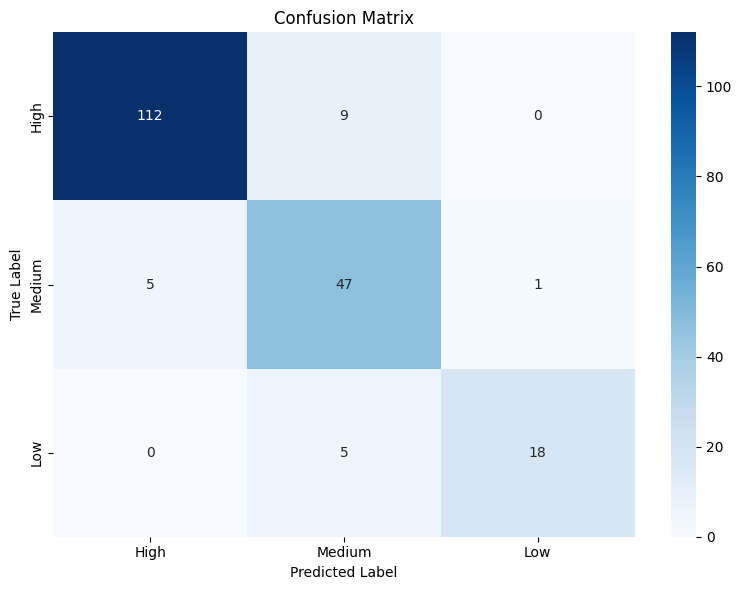

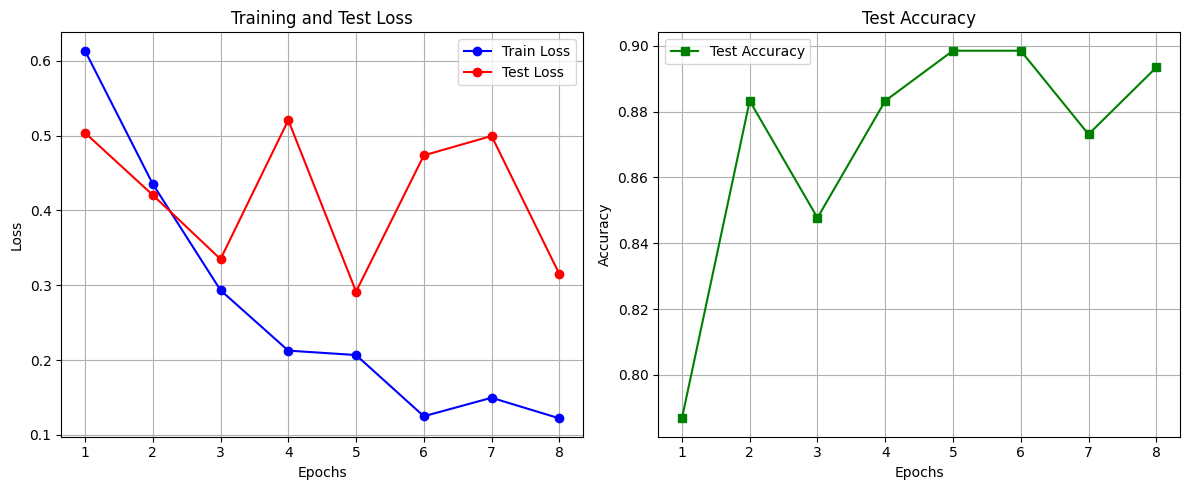


VISION TRANSFORMER MODEL

HYBRID MODEL

All models trained successfully.


In [ ]:
def main():
    # Initialising output paths and directories
    output_dir = 'outputs'
    models_dir = 'models'
    results_dir = 'results'
    plots_dir = 'plots'
    fi_dir = 'feature_importance'

    models_path = os.path.join(output_dir, models_dir)
    results_path = os.path.join(output_dir, results_dir)
    plots_path = os.path.join(output_dir, plots_dir)
    fi_path = os.path.join(output_dir, fi_dir)

    for p in [models_path, results_path, plots_path, fi_path]:
        if not os.path.exists(p):
            os.makedirs(p)

    # Loading the full dataset
    data_dir = '/content/data'

    DATASET_PATH = os.path.join(data_dir, 'annotated_dataset_v6.csv')

    # Define paths for your persistent, saved splits
    TRAIN_SPLIT_PATH = os.path.join(data_dir, 'train_split_v6.csv')
    TEST_SPLIT_PATH = os.path.join(data_dir, 'test_split_v6.csv')

    df = pd.read_csv(DATASET_PATH)

    df['screenshot_path'] = df['screenshot_path'].str.replace('\\', '/', regex=False)

    print("Dataset loaded successfully.")
    print("Dataset shape:", df.shape)

    # Checks if a train and test set already exist
    if os.path.exists(TRAIN_SPLIT_PATH) and os.path.exists(TEST_SPLIT_PATH):
        print("Found existing train/test split files! Loading them to ensure identical subsets...")
        train_df = pd.read_csv(TRAIN_SPLIT_PATH)
        test_df = pd.read_csv(TEST_SPLIT_PATH)

        # Ensure the string path adjustments carry over to the loaded sub-dataframes
        train_df['screenshot_path'] = train_df['screenshot_path'].str.replace('\\', '/', regex=False)
        test_df['screenshot_path'] = test_df['screenshot_path'].str.replace('\\', '/', regex=False)
    else:
        print("No existing split files found. Generating new master split and saving to disk...")
        train_df, test_df = train_test_split(
            df,
            test_size=0.2,
            random_state=42,
            stratify=df["accessibility_label"]
        )
        # Save them immediately so the NEXT run will be forced to use them
        train_df.to_csv(TRAIN_SPLIT_PATH, index=False)
        test_df.to_csv(TEST_SPLIT_PATH, index=False)

    X, y, feature_columns = load_dataset(DATASET_PATH)
    X_train = X.loc[train_df.index]
    X_test = X.loc[test_df.index]
    y_train = y.loc[train_df.index]
    y_test = y.loc[test_df.index]

    # Normalize/Scale features safely across the isolated sets
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
 
    # Initialise, optimise and train selected CNN model
    print("\n==============================")
    print("CNN MODEL")
    print("==============================")

    train_transform, test_transform = cnn_init_transform(IMG_SIZE)

    train_dataset, test_dataset = cnn_init_dataset(train_df, test_df, train_transform, test_transform)

    # Find the best parameters for the chosen CNN model
    print("\n--- Starting Phase 1: CNN Hyperparameter Optimization ---")
    log_resource_usage("Before Tuning/Training")
    start_time = time.time()
    best_cnn_params = tune_cnn(
        train_dt=train_dataset,
        test_dt=test_dataset,
        num_classes=3,
        n_trials=20
        # checkpoint_name="cnn_tuned_model"
    )
    end_time = time.time()
    tune_time = end_time - start_time
    print('Time taken to optimise the Convolutional Neural Network (CNN) model:', tune_time)

    # Train the definitive version
    print("\n--- Starting Phase 2: Training CNN Model ---")
    train_loader, test_loader = cnn_init_loader(train_dataset, test_dataset, batch_size=best_cnn_params['batch_size'])


    start_time = time.time()
    cnn_model, cnn_history, cnn_best_acc = train_cnn_model(
        train_loader=train_loader,
        test_loader=test_loader,
        num_classes=3,
        epochs=20,
        batch_size=best_cnn_params["batch_size"],
        lr=best_cnn_params["lr"],
        optimizer=best_cnn_params["optimizer"],
        weight_decay=best_cnn_params["weight_decay"],
        dropout=best_cnn_params["dropout"],
        checkpoint_name="cnn_production_final_vgg16"
    )

    final_model_save_path = os.path.join(models_path, "cnn_production_final_vgg16.pth")
    torch.save(cnn_model.state_dict(), final_model_save_path)
    print(f"Definitive production model saved securely to: {final_model_save_path}")

    end_time = time.time()
    train_time = end_time - start_time

    print('Time taken to train the Convolutional Neural Network (CNN) model:', train_time)

    print(f'CNN Best Accuracy: {cnn_best_acc}')

    print("\n--- Starting Phase 3: Evaluating CNN Performance ---")
    class_labels = ["High", "Medium", "Low"]

    cnn_metrics = evaluate_cnn_performance(
        model=cnn_model,
        test_df=test_df,
        batch_size=best_cnn_params["batch_size"],
        class_names=class_labels
    )

    plot_cnn_loss_graph(cnn_history)


if __name__ == "__main__":
    main()

In [ ]:
!zip -r outputs_cnn_v3.zip outputs/

  adding: outputs/ (stored 0%)
  adding: outputs/results/ (stored 0%)
  adding: outputs/plots/ (stored 0%)
  adding: outputs/plots/vit_training_metrics_.png (deflated 8%)
  adding: outputs/plots/cnn_confusion_matrix.png (deflated 18%)
  adding: outputs/plots/cnn_training_metrics_.png (deflated 8%)
  adding: outputs/plots/vit_b_16_confusion_matrix.png (deflated 18%)
  adding: outputs/models/ (stored 0%)
  adding: outputs/models/cnn_trial_15.pth (deflated 7%)
  adding: outputs/models/cnn_trial_11.pth (deflated 7%)
  adding: outputs/models/cnn_trial_8.pth (deflated 7%)
  adding: outputs/models/cnn_trial_18.pth (deflated 7%)
  adding: outputs/models/cnn_production_final_resnet18_v2.pth (deflated 7%)
  adding: outputs/models/cnn_trial_7.pth (deflated 7%)
  adding: outputs/models/cnn_trial_5.pth (deflated 7%)
  adding: outputs/models/cnn_trial_17.pth (deflated 7%)
  adding: outputs/models/cnn_trial_12.pth (deflated 7%)
  adding: outputs/models/cnn_trial_16.pth (deflated 7%)
  adding: outputs

In [ ]:
from google.colab import files
files.download('outputs_cnn_v3.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### VIT

Dataset loaded successfully.
Dataset shape: (982, 82)
Found existing train/test split files! Loading them to ensure identical subsets...

CLASSICAL ML PIPELINE
Loaded dataset: (982, 82)
Number of model features: 33

CNN MODEL

VISION TRANSFORMER MODEL

--- Starting Phase 1: Hyperparameter Optimization ---


/tmp/ipykernel_3298/851646130.py:166: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[feature] = pd.to_numeric(X[feature], errors="coerce")


--- [Resource Log: Before Tuning/Training] ---
RAM Usage: 2011.57 MB
System CPU Usage: 3.5%
-----------------------------------

--- Starting Phase 2: Training ViT Model ---
Using Optimal Parameters -> LR: 0.000063, Batch Size: 32


model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

Epoch [1/20] | Train Loss: 0.9383 | Test Loss: 0.5589 | Accuracy: 0.7462
--> Validation loss decreased. Saving best model model configuration...
Epoch [2/20] | Train Loss: 0.4339 | Test Loss: 0.5755 | Accuracy: 0.7563
EarlyStopping counter: 1 out of 3
Epoch [3/20] | Train Loss: 0.2961 | Test Loss: 0.5795 | Accuracy: 0.7665
EarlyStopping counter: 2 out of 3
Epoch [4/20] | Train Loss: 0.1922 | Test Loss: 0.3430 | Accuracy: 0.8782
--> Validation loss decreased. Saving best model model configuration...
Epoch [5/20] | Train Loss: 0.0921 | Test Loss: 0.5499 | Accuracy: 0.8680
EarlyStopping counter: 1 out of 3
Epoch [6/20] | Train Loss: 0.0672 | Test Loss: 0.2659 | Accuracy: 0.9036
--> Validation loss decreased. Saving best model model configuration...
Epoch [7/20] | Train Loss: 0.0440 | Test Loss: 0.3777 | Accuracy: 0.9036
EarlyStopping counter: 1 out of 3
Epoch [8/20] | Train Loss: 0.0270 | Test Loss: 0.4330 | Accuracy: 0.8782
EarlyStopping counter: 2 out of 3
Epoch [9/20] | Train Loss: 0.0

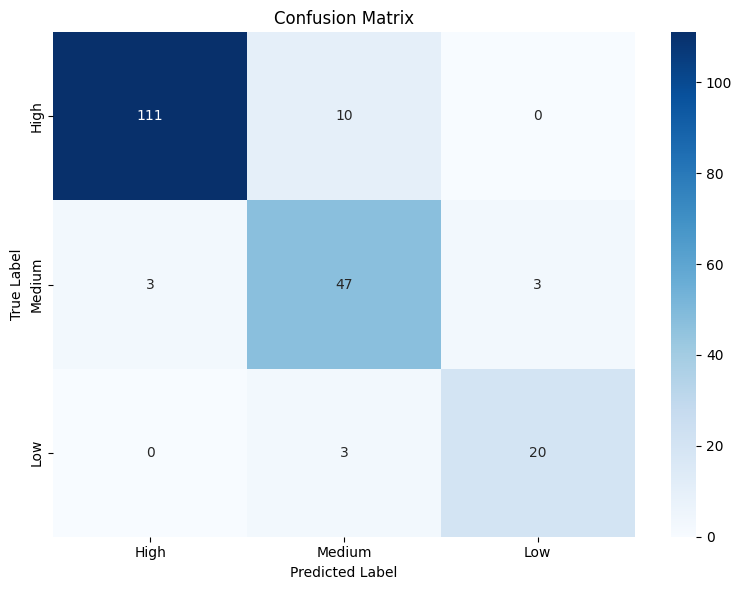

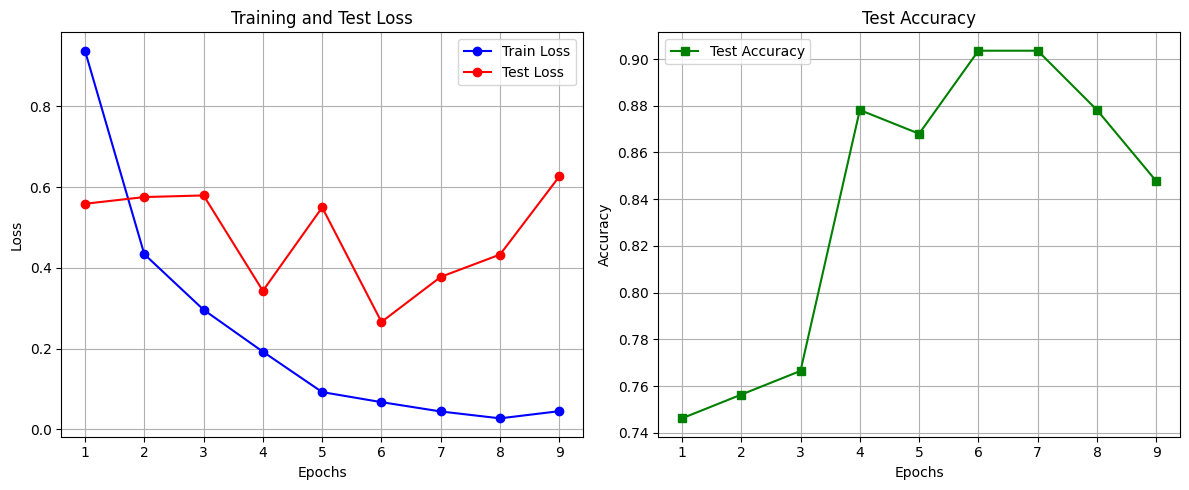


HYBRID MODEL

All models trained successfully.


In [ ]:
def main():
    # Initialising output paths and directories
    output_dir = 'outputs'
    models_dir = 'models'
    results_dir = 'results'
    plots_dir = 'plots'
    fi_dir = 'feature_importance'

    models_path = os.path.join(output_dir, models_dir)
    results_path = os.path.join(output_dir, results_dir)
    plots_path = os.path.join(output_dir, plots_dir)
    fi_path = os.path.join(output_dir, fi_dir)

    for p in [models_path, results_path, plots_path, fi_path]:
        if not os.path.exists(p):
            os.makedirs(p)

    # Loading the full dataset
    data_dir = '/content/data'

    DATASET_PATH = os.path.join(data_dir, 'annotated_dataset.csv')

    # Define paths for your persistent, saved splits
    TRAIN_SPLIT_PATH = os.path.join(data_dir, 'train_split.csv')
    TEST_SPLIT_PATH = os.path.join(data_dir, 'test_split.csv')

    df = pd.read_csv(DATASET_PATH)

    df['screenshot_path'] = df['screenshot_path'].str.replace('\\', '/', regex=False)

    print("Dataset loaded successfully.")
    print("Dataset shape:", df.shape)

    # Checks if a train and test set already exist
    if os.path.exists(TRAIN_SPLIT_PATH) and os.path.exists(TEST_SPLIT_PATH):
        print("Found existing train/test split files! Loading them to ensure identical subsets...")
        train_df = pd.read_csv(TRAIN_SPLIT_PATH)
        test_df = pd.read_csv(TEST_SPLIT_PATH)

        # Ensure the string path adjustments carry over to the loaded sub-dataframes
        train_df['screenshot_path'] = train_df['screenshot_path'].str.replace('\\', '/', regex=False)
        test_df['screenshot_path'] = test_df['screenshot_path'].str.replace('\\', '/', regex=False)
    else:
        print("No existing split files found. Generating new master split and saving to disk...")
        train_df, test_df = train_test_split(
            df,
            test_size=0.2,
            random_state=42,
            stratify=df["accessibility_label"]
        )
        # Save them immediately so the NEXT run will be forced to use them
        train_df.to_csv(TRAIN_SPLIT_PATH, index=False)
        test_df.to_csv(TEST_SPLIT_PATH, index=False)


    X, y, feature_columns = load_dataset(DATASET_PATH)

    X_train = X.loc[train_df.index]
    X_test = X.loc[test_df.index]
    y_train = y.loc[train_df.index]
    y_test = y.loc[test_df.index]

    # Normalize/Scale features safely across the isolated sets
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Initialise, optimise and train selected CNN model
    print("\n==============================")
    print("VISION TRANSFORMER MODEL")
    print("==============================")

    train_transform, test_transform = vit_init_transform(IMG_SIZE)

    train_dataset, test_dataset = vit_init_dataset(train_df, test_df, train_transform, test_transform)

    # train_loader, test_loader = vit_init_loader(train_dataset, test_dataset, batch_size=batch_size)

    # Run the Optuna tuning study wrapper
    print("\n--- Starting Phase 1: Hyperparameter Optimization ---")
    log_resource_usage("Before Tuning/Training")
    start_time = time.time()
    # best_vit_params = tune_vit(
    #     train_df=train_df,
    #     test_df=test_df,
    #     n_trials=20  # Adjust based on your computational/time budget
    #     # checkpoint_name="vit_tuned_model"
    # )
    best_vit_params = tune_vit(
        train_dt=train_dataset,
        test_dt=test_dataset,
        n_trials=10  # Adjust based on your computational/time budget
        # checkpoint_name="vit_tuned_model"
    )
    end_time = time.time()
    tune_time = end_time - start_time
    print('Time taken to optimise the Vision Transformer (ViT) model:', tune_time)
    log_resource_usage("After Optuna Tuning")

    # best_vit_params = {'lr': 6.256467090059036e-05, 'batch_size': 32, 'weight_decay': 0.0001303647899127471, 'dropout': 0.2, 'drop_path': 0.19402465492617574, 'attn_drop': 0.09161499803043077}
    # best_vit_params = {'lr': 0.00012262327041875912, 'batch_size': 16, 'weight_decay': 0.0033944689138284624, 'dropout': 0.0, 'stochastic_depth_prob': 0.4, 'attention_dropout': 0.0} - SWIN-T

    train_loader, test_loader = vit_init_loader(train_dataset, test_dataset, batch_size=best_vit_params['batch_size'])

    # Step B: Pass optimized metrics into your production training runner
    print("\n--- Starting Phase 2: Training ViT Model ---")
    print(f"Using Optimal Parameters -> Learning Rate: {best_vit_params['lr']:.6f}, Batch Size: {best_vit_params['batch_size']}, Weight Decay: {best_vit_params['weight_decay']}, Dropout: {best_vit_params['dropout']}, Drop Path: {best_vit_params['drop_path']}, Attention Dropout: {best_vit_params['attn_drop']}")
    # print(f"Using Optimal Parameters -> Learning Rate: {best_vit_params['lr']:.6f}, Batch Size: {best_vit_params['batch_size']}, Weight Decay: {best_vit_params['weight_decay']}, Dropout: {best_vit_params['dropout']}, Depth Probability: {best_vit_params['stochastic_depth_prob']}, Attention Dropout: {best_vit_params['attention_dropout']}")   --- UNCOMMENT THIS IF BUILDING A SWIN-T MODEL

    start_time = time.time()

    vit_model, vit_history, vit_best_acc = train_vit_model(
        train_loader=train_loader,
        test_loader=test_loader,
        num_classes=3,
        epochs=20,  # A generous ceiling; early stopping handles structural convergence
        batch_size=best_vit_params["batch_size"],
        lr=best_vit_params["lr"],
        weight_decay=best_vit_params["weight_decay"],
        dropout=best_vit_params["dropout"],
        drop_path=best_vit_params["drop_path"],
        attn_drop=best_vit_params["attn_drop"],
        checkpoint_name="vit_b_16_production_final_v3"
    )

    final_model_save_path = os.path.join(models_path, "vit_b_16_production_final_v3.pth")
    torch.save(vit_model.state_dict(), final_model_save_path)
    print(f"Definitive production model saved securely to: {final_model_save_path}")

    end_time = time.time()
    train_time = end_time - start_time

    print('Time taken to train the Vision Transformer (ViT) model:', train_time)

    print(f'ViT Best Accuracy: {vit_best_acc}')

    print("\n--- Starting Phase 3: Evaluating ViT Performance ---")
    class_labels = ["High", "Medium", "Low"]

    # One clean, self-contained call passes the raw dataframe right back down!
    vit_metrics = evaluate_vit_performance(
        model=vit_model,
        test_df=test_df,
        batch_size=best_vit_params["batch_size"],
        class_names=class_labels
    )

    plot_vit_loss_graph(vit_history)

if __name__ == "__main__":
    main()

In [ ]:
!zip -r outputs_vit_v2.zip outputs/

updating: outputs/ (stored 0%)
updating: outputs/results/ (stored 0%)
updating: outputs/plots/ (stored 0%)
updating: outputs/plots/vit_training_metrics_.png (deflated 8%)
updating: outputs/plots/cnn_confusion_matrix.png (deflated 18%)
updating: outputs/plots/cnn_training_metrics_.png (deflated 9%)
updating: outputs/plots/vit_b_16_confusion_matrix.png (deflated 18%)
updating: outputs/models/ (stored 0%)
updating: outputs/models/cnn_trial_15.pth (deflated 7%)
updating: outputs/models/cnn_trial_11.pth (deflated 7%)
updating: outputs/models/cnn_trial_8.pth (deflated 7%)
updating: outputs/models/cnn_trial_10.pth (deflated 7%)
updating: outputs/models/vit_trial_7.pth (deflated 7%)
updating: outputs/models/cnn_production_final_resnet18_v2.pth (deflated 7%)
updating: outputs/models/cnn_trial_7.pth (deflated 7%)
updating: outputs/models/cnn_trial_5.pth (deflated 7%)
updating: outputs/models/cnn_trial_17.pth (deflated 7%)
updating: outputs/models/vit_b_16_production_final_v2 (deflated 7%)
updati

In [ ]:
from google.colab import files
files.download('/content/outputs/models/vit_b_16_production_final_v2_.pth')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>